Evaluacion Parcial 1

Exploracion y Preprocesamiento de Datos

Siniestros de Transito Urbanos, Chile 2024

Integrantes: Andres Zuñiga Saavedra

Fecha: 10-09-2026

Este informe presenta el preprocesamiento del archivo siniestro_urbano_2024_proyecto.csv,
que contiene registros de siniestros de transito ocurridos en zonas urbanas de Chile durante 2024.

El objetivo es dejar el conjunto de datos listo para ser usado en modelos
de Machine Learning, considerando:

1. Descripcion general del conjunto de datos
2. Seleccion de variables relevantes
3. Deteccion y manejo de valores faltantes y atipicos
4. Analisis de correlacion y manejo de variables
5. Escalado y codificacion de variables


In [22]:
%pip install numpy pandas matplotlib scikit-learn seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [23]:
# Importar librerias necesarias para analisis, visualizacion y preprocesamiento
# pandas: permite cargar y manipular dataframes
# numpy: facilita calculos numericos y arrays
# matplotlib/seaborn: generan graficos para explorar datos
# stats.linregress: calcula regresion lineal para imputar valores faltantes
# StandardScaler, MinMaxScaler, OneHotEncoder: normalizan, escalan y codifican variables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# set_option(): configura la visualizacion de columnas del dataframe
pd.set_option('display.max_columns', None)
# set_theme(): aplica estilo visual a los graficos
sns.set_theme(style='whitegrid')
# %matplotlib inline: muestra graficos dentro del notebook
%matplotlib inline


1. Descripcion general del conjunto de datos

Se carga el archivo y se revisan sus dimensiones, tipos de datos y una vista inicial de
los registros para entender la informacion antes de hacer transformaciones.


In [2]:
# read_csv(): carga el archivo CSV en un DataFrame
# head(): muestra las primeras filas para revisar la estructura del dataset
# df.shape: devuelve las dimensiones del DataFrame (filas, columnas)


df = pd.read_csv('siniestro_urbano_2024_proyecto.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 55663 filas x 33 columnas


,X,Y,FID,IdAccident,Fecha,Diames,Diasemana,Mes,Año,Hora,Hora_aprox,Región,Comuna,Tipo__CONA,Zona,Causa__CON,Fallecidos,Lesionados,Graves,Menos_Grav,Leves,CUT_REG,CUT_COM,REGION_DPA,COMUNA_DPA,Ciudad,Lat,Lon,Turno,DiaSemana_Cat,Turno_encoded,DiaSemana_encoded,Outlier_Inyectado
0,-7.858843e+06,-3.964383e+06,1,1585801,2024/01/17 00:00:00+00,17,3,1,2024,1899/12/30 00:00:00+00,NaN,REGION METROPOLITANA,LA FLORIDA,COLISION,URBANA,NaN,0,1,0,0,1,13,13110,Metropolitana de Santiago,La Florida,Gran Santiago,-33.518892,-70.597185,Tarde,Miércoles,2,2,False
1,-7.865214e+06,-3.952027e+06,2,1585803,2024/01/16 00:00:00+00,16,2,1,2024,1899/12/30 00:00:00+00,18.0,REGION METROPOLITANA,INDEPENDENCIA,COLISION,URBANA,DESOBEDIENCIA A SEÑALIZACION,0,1,1,0,0,13,13108,Metropolitana de Santiago,Independencia,Gran Santiago,-33.426311,-70.654419,Tarde,Martes,2,1,False
2,-7.860285e+06,-3.956790e+06,3,1585807,2024/01/18 00:00:00+00,18,4,1,2024,1899/12/30 00:00:00+00,9.0,REGION METROPOLITANA,NUNOA,COLISION,URBANA,IMPRUDENCIA DEL CONDUCTOR,0,0,0,0,0,13,13120,Metropolitana de Santiago,Ñuñoa,Gran Santiago,-33.462010,NaN,Mañana,Jueves,1,3,False
3,-7.858920e+06,-3.956247e+06,4,1585808,2024/01/18 00:00:00+00,18,4,1,2024,1899/12/30 00:00:00+00,9.0,REGION METROPOLITANA,NUNOA,COLISION,URBANA,IMPRUDENCIA DEL CONDUCTOR,0,0,0,0,0,13,13120,Metropolitana de Santiago,Ñuñoa,Gran Santiago,-33.457942,-70.597879,Mañana,Jueves,1,3,False
4,-7.860878e+06,-3.871749e+06,5,1585809,2024/01/15 00:00:00+00,15,1,1,2024,1899/12/30 00:00:00+00,17.0,REGION VALPARAISO,LOS ANDES,CHOQUE,URBANA,IMPRUDENCIA DEL CONDUCTOR,0,0,0,0,0,5,5301,Valparaíso,Los Andes,Otra,-32.822357,-70.615465,Tarde,Lunes,2,0,False


In [3]:
# info(): muestra tipos de dato, cantidad de columnas y valores nulos por variable
# Ayuda a identificar variables numericas, categoricas y con datos faltantes
# df.info() proporciona un resumen conciso del DataFrame, incluyendo el número de entradas,
# el tipo de índice, el número de columnas, los nombres de las columnas, el conteo de valores
# no nulos y el tipo de datos de cada columna. Esto es útil para obtener una visión general
# rápida del dataset y para identificar posibles problemas de calidad de datos.

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 55663 entries, 0 to 55662
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   X                  55663 non-null  float64
 1   Y                  55663 non-null  float64
 2   FID                55663 non-null  int64  
 3   IdAccident         55663 non-null  int64  
 4   Fecha              55663 non-null  str    
 5   Diames             55663 non-null  int64  
 6   Diasemana          55663 non-null  int64  
 7   Mes                55663 non-null  int64  
 8   Año                55663 non-null  int64  
 9   Hora               55663 non-null  str    
 10  Hora_aprox         44530 non-null  float64
 11  Región             55663 non-null  str    
 12  Comuna             55663 non-null  str    
 13  Tipo__CONA         55663 non-null  str    
 14  Zona               55663 non-null  str    
 15  Causa__CON         44530 non-null  str    
 16  Fallecidos         55663 non-null

In [4]:
# describe(): calcula estadisticos descriptivos de variables numericas
# Toma medidas como media, desviacion estandar, cuartiles y maximos

df.describe().T


,count,mean,std,min,25%,50%,75%,max
X,55663.0,-7.949790e+06,148630.829074,-1.218224e+07,-8.051514e+06,-7.895699e+06,-7.862953e+06,-7.524693e+06
Y,55663.0,-4.053275e+06,723135.152380,-7.348972e+06,-4.409785e+06,-3.967561e+06,-3.943428e+06,-2.084064e+06
FID,55663.0,2.780901e+04,16056.556667,1.000000e+00,1.390350e+04,2.780700e+04,4.171350e+04,5.562300e+04
IdAccident,55663.0,1.623145e+06,22587.119573,1.581186e+06,1.603770e+06,1.623263e+06,1.642615e+06,1.662380e+06
Diames,55663.0,1.523712e+01,8.753079,1.000000e+00,8.000000e+00,1.500000e+01,2.300000e+01,3.100000e+01
Diasemana,55663.0,3.875285e+00,1.952704,1.000000e+00,2.000000e+00,4.000000e+00,6.000000e+00,7.000000e+00
Mes,55663.0,6.561055e+00,3.405912,1.000000e+00,4.000000e+00,7.000000e+00,1.000000e+01,1.200000e+01
Año,55663.0,2.024000e+03,0.000000,2.024000e+03,2.024000e+03,2.024000e+03,2.024000e+03,2.024000e+03
Hora_aprox,44530.0,1.348367e+01,5.547187,0.000000e+00,9.000000e+00,1.400000e+01,1.800000e+01,2.300000e+01
Fallecidos,55663.0,9.306002e-03,0.173791,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.200000e+01


In [5]:
# describe(include='object'): calcula estadisticos para variables categoricas(que no son numeros sino caracteristica ejemplo colores, marcas, etc)
# Permite ver el numero de valores unicos y una vista inicial de cada categoria
# Transpose (T) para mostrar las variables como filas y estadisticos como columnas.
df.describe(include='object').T


C:\Users\andre\AppData\Local\Temp\ipykernel_5396\357059837.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object').T


,count,unique,top,freq
Fecha,55663,366,2024/05/03 00:00:00+00,231
Hora,55663,1,1899/12/30 00:00:00+00,55663
Región,55663,16,REGION METROPOLITANA,19917
Comuna,55663,312,TEMUCO,1916
Tipo__CONA,55663,7,COLISION,31727
Zona,55663,1,URBANA,55663
Causa__CON,44530,13,IMPRUDENCIA DEL CONDUCTOR,32939
REGION_DPA,55663,16,Metropolitana de Santiago,19917
COMUNA_DPA,55663,312,Temuco,1916
Ciudad,55663,9,Otra,22821


Interpretacion general: el conjunto de datos contiene 55.663 registros y 33 variables,
correspondientes a siniestros de transito ocurridos en zonas urbanas. La variable Zona
es constante, por lo que no aporta informacion para distinguir entre clases o grupos.

Las variables numericas describen la ubicacion geografica (X, Y, Lat, Lon), la fecha y
la hora del accidente (Diames, Diasemana, Mes, Año, Hora_aprox) y la cantidad de
victimas (Fallecidos, Lesionados, Graves, Menos_Grav, Leves).

Las variables categoricas describen la ubicacion administrativa (Region, Comuna, Ciudad),
el tipo y la causa del siniestro (Tipo__CONA, Causa__CON) y variables temporales
categorizadas (Turno, DiaSemana_Cat). Ademas, existen columnas que son versiones
codificadas de otras (Turno_encoded, DiaSemana_encoded) y una columna Outlier_Inyectado
que marca registros con valores atipicos introducidos de forma controlada para el ejercicio.


2. Deteccion y manejo de valores faltantes y atipicos

2.1 Valores faltantes


In [6]:
# isnull(): detecta valores faltantes por columna
# sum(): cuenta cuantas observaciones tienen datos vacios en cada variable
# sort_values(): ordena las columnas por cantidad de faltantes de mayor a menor
# round(): redondea el porcentaje para una lectura mas clara
# ascending=False: ordena de mayor a menor
# porcentaje_faltantes = (faltantes / len(df) * 100).round(2): calcula el porcentaje de faltantes respecto al total

faltantes = df.isnull().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
porcentaje_faltantes = (faltantes / len(df) * 100).round(2)
pd.DataFrame({'faltantes': faltantes, '% del total': porcentaje_faltantes})


,faltantes,% del total
Hora_aprox,11133,20.0
Causa__CON,11133,20.0
Lon,11133,20.0


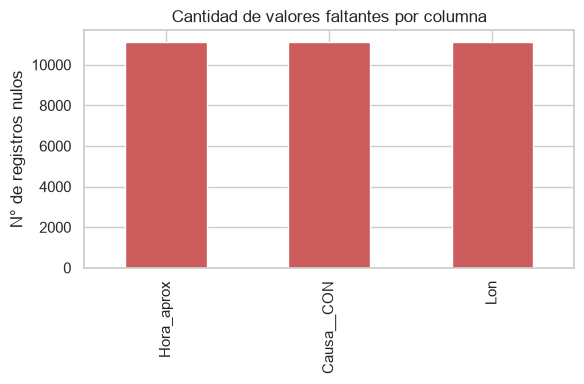

In [7]:
# plot(kind='bar'): genera un grafico de barras para visualizar los faltantes por columna
# bar(): ayuda a comparar la cantidad de datos faltantes entre variables
# figsize=(6,4): define el tamaño del grafico
# plt.tight_layout(): ajusta el espaciado de los elementos del grafico para evitar superposiciones
# fig, ax refiere a la figura y los ejes del grafico, permitiendo personalizarlo
# faltantes.plot(kind='bar', ax=ax, color='indianred') genera un grafico de barras con la cantidad de faltantes por columna
# plt.show(): muestra el grafico generado
# plt.title('Cantidad de valores faltantes por columna') agrega un titulo al grafico

fig, ax = plt.subplots(figsize=(6,4))
faltantes.plot(kind='bar', ax=ax, color='indianred')
ax.set_title('Cantidad de valores faltantes por columna')
ax.set_ylabel('N° de registros nulos')
plt.tight_layout()
plt.show()


Se identifican valores faltantes en tres columnas: Hora_aprox, Causa__CON y Lon,
todas con 11.133 registros nulos, aproximadamente 20% del total. Se revisa si estos
nulos coinciden en las mismas filas para decidir la mejor estrategia de tratamiento.


In [8]:
# isnull(): identifica los valores faltantes en cada columna seleccionada
# sum(axis=1): suma la cantidad de faltantes por fila para ver si coinciden
# == 3 y >= 1: permiten comparar si los faltantes ocurren juntos o por separado

marca_faltantes = df[['Hora_aprox','Causa__CON','Lon']].isnull()
print("Filas con los 3 faltantes a la vez:", (marca_faltantes.sum(axis=1)==3).sum())
print("Filas con al menos 1 faltante:", (marca_faltantes.sum(axis=1)>=1).sum())


Filas con los 3 faltantes a la vez: 422
Filas con al menos 1 faltante: 27169


Estrategia de imputacion:

- Causa__CON (categorica): se reemplaza por la categoria "SIN INFORMACION", porque la falta de informacion es en si misma relevante y no conviene usar la moda por defecto.
- Hora_aprox (numerica, hora del dia): se reemplaza por la mediana, ya que es una medida robusta para una variable circular y con sesgo.
- Lon (numerica, coordenada geografica): se reemplaza usando la relacion lineal entre X y Lon en los registros completos, para no distorsionar la ubicacion real del siniestro.


In [9]:
# fillna(): reemplaza valores faltantes con una categoria o valor definido
# median(): calcula la mediana para imputar la hora faltante
# dropna(): elimina filas con valores faltantes para construir una base de apoyo para la regresion
# linregress(): ajusta una regresion lineal entre X y Lon para estimar valores faltantes

# Imputacion de Causa__CON
# Se rellena con una categoria explicita para mantener la informacion de ausencia de dato

df['Causa__CON'] = df['Causa__CON'].fillna('SIN INFORMACION')

# Imputacion de Hora_aprox con la mediana
# La mediana es una medida robusta ante valores extremos y sesgos
hora_media = df['Hora_aprox'].median()
df['Hora_aprox'] = df['Hora_aprox'].fillna(hora_media)

# Imputacion de Lon usando regresion lineal simple con X
# Se usa la relacion entre variables geograficas para estimar valores faltantes con mayor precision
base_completa = df.dropna(subset=['Lon'])
pendiente, intercepto, r, p, se = stats.linregress(base_completa['X'], base_completa['Lon'])
print(f"R^2 de la relacion X -> Lon: {r**2:.4f}")

filas_con_lon_vacia = df['Lon'].isnull()
df.loc[filas_con_lon_vacia, 'Lon'] = pendiente * df.loc[filas_con_lon_vacia, 'X'] + intercepto

print("Valores nulos restantes:")
print(df.isnull().sum().sum())


R^2 de la relacion X -> Lon: 1.0000
Valores nulos restantes:
0


2.2 Valores atipicos (outliers)

Se usa el metodo estadistico del rango intercuartil (IQR) sobre las variables numericas
 de conteo de victimas, que son las mas relevantes para el analisis, y se compara con la
 columna Outlier_Inyectado incluida en el propio dataset.


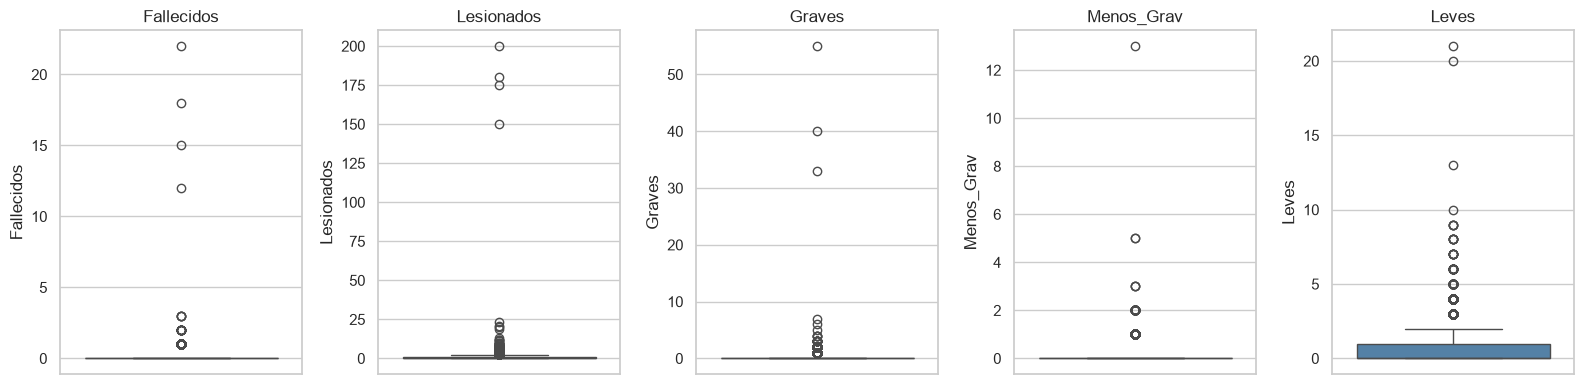

In [10]:
# boxplot(): crea diagramas de caja para visualizar la dispersion y valores extremos de cada variable
# ayuda a detectar valores muy altos o muy bajos que pueden ser atipicos reales

columnas_victimas = ['Fallecidos','Lesionados','Graves','Menos_Grav','Leves']

fig, axes = plt.subplots(1, len(columnas_victimas), figsize=(16,4))
for ax, col in zip(axes, columnas_victimas):
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [11]:
# quantile(): obtiene los percentiles 25 y 75 para calcular el rango intercuartil
# IQR se usa para identificar valores atipicos fuera del rango esperado
# ((serie < lim_inf) | (serie > lim_sup)).sum(): cuenta cuantos datos estan fuera del rango

def resumen_de_atipicos(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
    valores_fuera = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return lim_inf, lim_sup, valores_fuera

resumen = []
for col in columnas_victimas:
    lim_bajo, lim_alto, cantidad_fuera = resumen_de_atipicos(df[col])
    resumen.append([col, lim_bajo, lim_alto, cantidad_fuera, round(cantidad_fuera/len(df)*100,2)])

pd.DataFrame(resumen, columns=['Variable','Límite inf.','Límite sup.','N° outliers','% outliers'])


,Variable,Límite inf.,Límite sup.,N° outliers,% outliers
0,Fallecidos,0.0,0.0,430,0.77
1,Lesionados,-1.5,2.5,1103,1.98
2,Graves,0.0,0.0,3653,6.56
3,Menos_Grav,0.0,0.0,1661,2.98
4,Leves,-1.5,2.5,852,1.53


In [12]:
# value_counts(): resume cuantas filas tienen cada valor en la columna de control
# Esto permite verificar cuan frecuente es la marca de atipico inyectado
# Outlier_Inyectado es una columna creada para marcar registros que fueron modificados para simular outliers

print(df['Outlier_Inyectado'].value_counts())
df[df['Outlier_Inyectado']][columnas_victimas + ['Outlier_Inyectado']]


Outlier_Inyectado
False    55653
True        10
Name: count, dtype: int64


,Fallecidos,Lesionados,Graves,Menos_Grav,Leves,Outlier_Inyectado
4387,0,2,40,0,2,True
5611,0,0,55,0,0,True
21051,0,1,33,0,1,True
25111,0,1,0,1,0,True
36429,0,0,0,0,0,True
44307,18,0,0,0,0,True
51138,0,0,0,0,0,True
51343,12,0,0,0,0,True
52076,15,1,0,0,1,True
52115,22,0,0,0,0,True


Gestion de outliers:

dado que las variables de victimas (Fallecidos, Lesionados, etc.) son conteos con
 distribucion muy sesgada, los valores altos pueden ser eventos reales y no necesariamente
 errores; eliminarlos significaria perder informacion importante para el modelo. Por eso:

- Se conservan los outliers naturales detectados por IQR en las variables de victimas,
  porque reflejan siniestros reales de mayor gravedad.
- Solo se tratan los registros marcados en Outlier_Inyectado = True (10 registros),
  aplicando un capping al percentil 99 de cada variable, porque corresponden a valores
  artificialmente introducidos y no a observaciones reales del fenomeno.


In [13]:
# quantile(0.99): obtiene el percentil 99 para aplicar un tope a valores extremos
# loc[]: selecciona solo registros marcados como atipicos inyectados
# Se usa un tope para limitar valores artificialmente altos sin perder la estructura general del dataset

for col in columnas_victimas:
    percentil_99 = df[col].quantile(0.99)
    filtro = df['Outlier_Inyectado'] & (df[col] > percentil_99)
    df.loc[filtro, col] = percentil_99

print("Verificacion post-tratamiento en registros inyectados:")
df[df['Outlier_Inyectado']][columnas_victimas]


Verificacion post-tratamiento en registros inyectados:


,Fallecidos,Lesionados,Graves,Menos_Grav,Leves
4387,0,2,1,0,2
5611,0,0,1,0,0
21051,0,1,1,0,1
25111,0,1,0,1,0
36429,0,0,0,0,0
44307,0,0,0,0,0
51138,0,0,0,0,0
51343,0,0,0,0,0
52076,0,1,0,0,1
52115,0,0,0,0,0


2.3 Evaluacion del efecto del tratamiento

Se comparan las distribuciones antes y despues del tratamiento de atipicos y faltantes para
verificar que la forma general de los datos no se haya alterado demasiado.


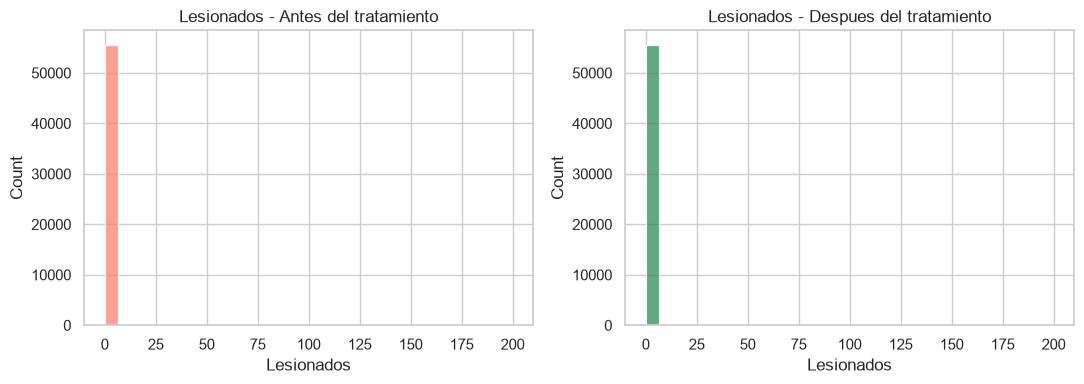

Media antes: 0.4538  | Media despues: 0.4538
Desv. estandar antes: 1.6884  | Desv. estandar despues: 1.6884


In [14]:
# read_csv(): vuelve a cargar el archivo original para comparar resultados antes y despues
# histplot(): genera histogramas para evaluar cambios en la distribucion de Lesionados
# mean(): calcula la media antes y despues del tratamiento
# std(): calcula la desviacion estandar para revisar si la variabilidad se mantiene

df_original = pd.read_csv('siniestro_urbano_2024_proyecto.csv')

fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.histplot(df_original['Lesionados'], bins=30, ax=axes[0], color='salmon')
axes[0].set_title('Lesionados - Antes del tratamiento')
sns.histplot(df['Lesionados'], bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Lesionados - Despues del tratamiento')
plt.tight_layout()
plt.show()

print("Media antes:", df_original['Lesionados'].mean().round(4),
      " | Media despues:", df['Lesionados'].mean().round(4))
print("Desv. estandar antes:", df_original['Lesionados'].std().round(4),
      " | Desv. estandar despues:", df['Lesionados'].std().round(4))


Se observa que el tratamiento aplicado (capping de solo 10 registros inyectados)
no altera significativamente la media ni la desviacion estandar de las variables de
victimas, confirmando que la intervencion fue puntual y mantuvo la distribucion real
 del fenomeno de siniestros.


3. Analisis de correlacion y seleccion de variables

3.1 Matriz de correlacion entre variables numericas


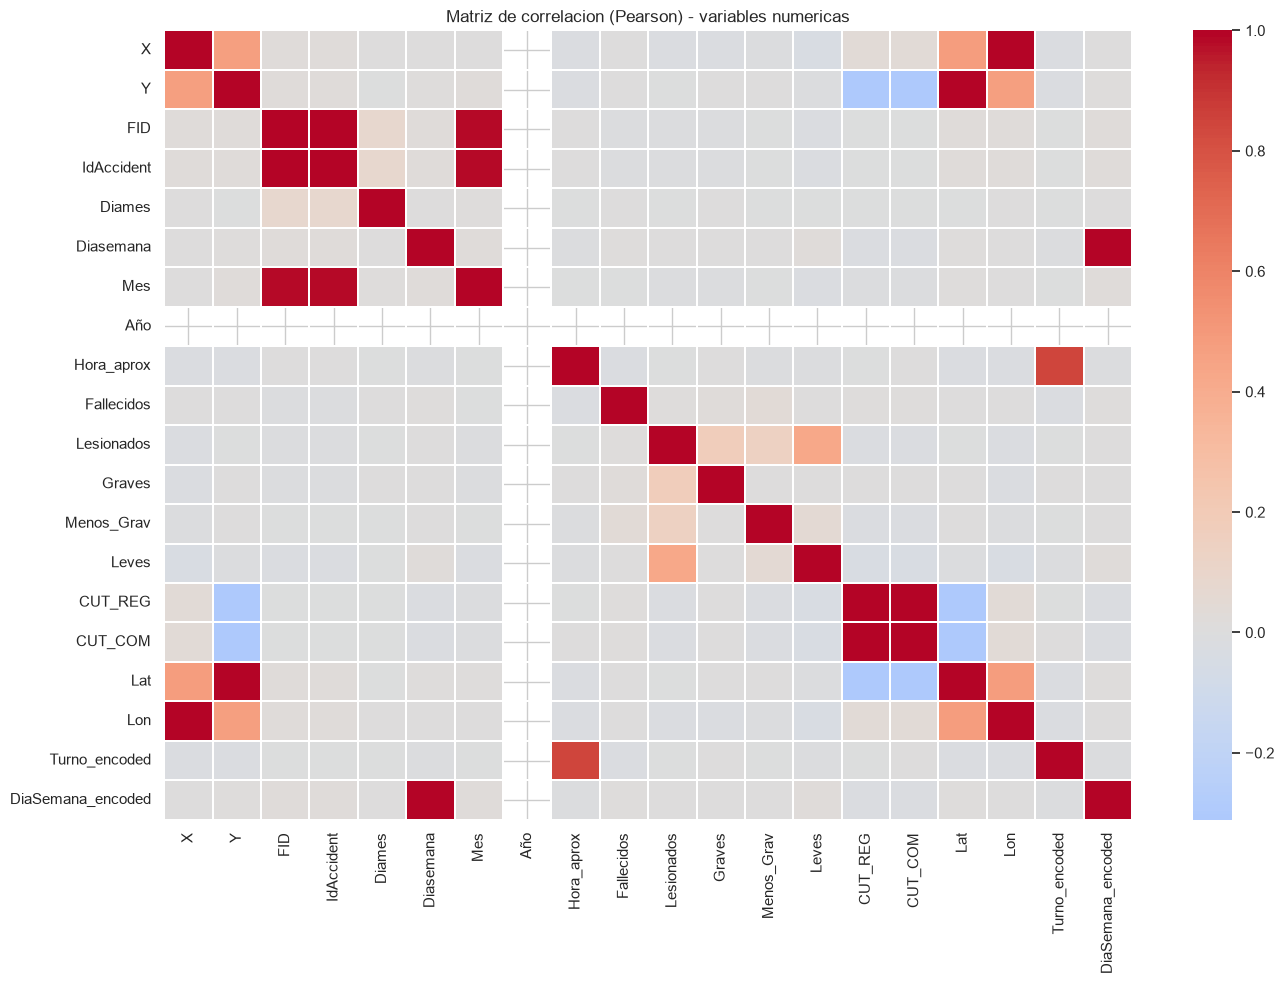

In [15]:
# select_dtypes(include=[np.number]): selecciona solo columnas numericas
# corr(method='pearson'): calcula la matriz de correlacion de Pearson
# heatmap(): dibuja la matriz de correlacion para visualizar relaciones

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr(method='pearson')

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Matriz de correlacion (Pearson) - variables numericas')
plt.tight_layout()
plt.show()


In [16]:
# abs(): convierte los valores de correlacion en sus valores absolutos
# where(): elimina la diagonal principal para comparar solo pares distintos
# triu(): toma la parte triangular superior de la matriz
# stack(): convierte la matriz en una serie con pares de columnas y su correlacion
# sort_values(): ordena las correlaciones de mayor a menor para encontrar redundancias

corr_abs = corr.abs()
pares = (corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
                 .stack()
                 .sort_values(ascending=False))
pares[pares > 0.85]


Diasemana   DiaSemana_encoded    1.000000
X           Lon                  1.000000
CUT_REG     CUT_COM              0.999289
FID         IdAccident           0.998841
Y           Lat                  0.994798
IdAccident  Mes                  0.987957
FID         Mes                  0.987081
dtype: float64

Interpretacion: se identifican pares de variables con correlacion muy alta (|r| > 0.85),
lo que indica redundancia de informacion:

- X / Y vs Lon / Lat: representan la misma ubicacion geografica en dos sistemas distintos.
- FID vs IdAccident: ambos son identificadores unicos, sin valor predictivo.
- Diames, Mes, Diasemana vs sus versiones codificadas y categoricas: repiten la misma informacion temporal.
- CUT_REG / CUT_COM vs Region / Comuna / REGION_DPA / COMUNA_DPA: son codigos administrativos que describen lo mismo.
- Lesionados es aproximadamente la suma de Graves + Menos_Grav + Leves, por lo que aporta informacion redundante respecto a sus componentes.

### 3.2 Manejo de variables

Justificacion de eliminacion o conservacion:

| Variable | Decision | Justificacion |
|---|---|---|
| FID, IdAccident | Eliminar | Identificadores unicos, sin poder predictivo |
| X, Y | Eliminar | Redundantes con Lat/Lon |
| CUT_REG, CUT_COM | Eliminar | Codigos administrativos redundantes |
| REGION_DPA, COMUNA_DPA | Eliminar | Duplican Region y Comuna |
| Zona | Eliminar | Constante, no aporta variabilidad |
| Diames, Mes | Conservar Mes; eliminar Diames si se prioriza la estacionalidad mensual | Se conserva Mes como variable temporal relevante |
| Diasemana, DiaSemana_Cat, DiaSemana_encoded | Conservar solo DiaSemana_encoded | Ya esta codificada numericamente |
| Turno, Turno_encoded | Conservar solo Turno_encoded | Misma logica anterior |
| Lesionados | Eliminar | Es la suma de Graves + Menos_Grav + Leves |
| Ciudad, Comuna | Conservar Comuna | Tiene mayor granularidad |

Esta seleccion reduce la dimensionalidad del conjunto de datos y evita que los modelos
asignen peso duplicado a la misma informacion geografica, temporal o administrativa.


In [17]:
# drop(columns=...): elimina columnas redundantes o sin valor predictivo
# Esto reduce la dimensionalidad y evita duplicidad de informacion en el modelo

columnas_a_eliminar = [
    'FID','IdAccident','X','Y','CUT_REG','CUT_COM','REGION_DPA','COMUNA_DPA',
    'Zona','Diames','Diasemana','DiaSemana_Cat','Turno','Lesionados'
]
df_reducido = df.drop(columns=columnas_a_eliminar)
print(f"Dimensiones tras la seleccion de variables: {df_reducido.shape}")
df_reducido.head()


Dimensiones tras la seleccion de variables: (55663, 19)


,Fecha,Mes,Año,Hora,Hora_aprox,Región,Comuna,Tipo__CONA,Causa__CON,Fallecidos,Graves,Menos_Grav,Leves,Ciudad,Lat,Lon,Turno_encoded,DiaSemana_encoded,Outlier_Inyectado
0,2024/01/17 00:00:00+00,1,2024,1899/12/30 00:00:00+00,14.0,REGION METROPOLITANA,LA FLORIDA,COLISION,SIN INFORMACION,0,0,0,1,Gran Santiago,-33.518892,-70.597185,2,2,False
1,2024/01/16 00:00:00+00,1,2024,1899/12/30 00:00:00+00,18.0,REGION METROPOLITANA,INDEPENDENCIA,COLISION,DESOBEDIENCIA A SEÑALIZACION,0,1,0,0,Gran Santiago,-33.426311,-70.654419,2,1,False
2,2024/01/18 00:00:00+00,1,2024,1899/12/30 00:00:00+00,9.0,REGION METROPOLITANA,NUNOA,COLISION,IMPRUDENCIA DEL CONDUCTOR,0,0,0,0,Gran Santiago,-33.462010,-70.610142,1,3,False
3,2024/01/18 00:00:00+00,1,2024,1899/12/30 00:00:00+00,9.0,REGION METROPOLITANA,NUNOA,COLISION,IMPRUDENCIA DEL CONDUCTOR,0,0,0,0,Gran Santiago,-33.457942,-70.597879,1,3,False
4,2024/01/15 00:00:00+00,1,2024,1899/12/30 00:00:00+00,17.0,REGION VALPARAISO,LOS ANDES,CHOQUE,IMPRUDENCIA DEL CONDUCTOR,0,0,0,0,Otra,-32.822357,-70.615465,2,0,False


4. Escalamiento y codificacion de variables

4.1 Escalamiento de variables numericas

Antes de escalar, se revisa la distribucion de cada variable numerica para elegir la tecnica
mas apropiada.


In [18]:
# select_dtypes(include=[np.number]): selecciona columnas numericas para revisar su asimetria
# skew(): calcula la asimetria de cada variable para decidir el metodo de escalado

num_cols_final = df_reducido.select_dtypes(include=[np.number]).columns.tolist()
asimetria = df_reducido[num_cols_final].skew().sort_values(ascending=False)
asimetria


Fallecidos           13.223241
Menos_Grav           11.355989
Graves                4.628121
Leves                 3.756231
Lat                   0.428770
DiaSemana_encoded     0.036221
Año                   0.000000
Mes                  -0.001334
Turno_encoded        -0.278378
Hora_aprox           -0.491092
Lon                 -12.241247
dtype: float64

Justificacion: las variables de conteo de victimas (Fallecidos, Graves, Menos_Grav, Leves)
presentan una distribucion muy sesgada, con muchos ceros y pocos valores altos. Por eso se
usa MinMaxScaler, que no asume una distribucion normal y es menos sensible a valores extremos
ya tratados antes. Para variables con distribucion mas equilibrada y mayor rango, como Hora_aprox,
Lat y Lon, se usa StandardScaler, que es adecuado cuando la escala natural no tiene un minimo y
maximo claros.


In [19]:
# MinMaxScaler(): escala variables entre 0 y 1 para conteos sesgados
# StandardScaler(): centra y escala variables continuas con distribucion mas balanceada
# fit_transform(): ajusta los parametros del scaler y transforma los datos

cols_minmax = ['Fallecidos','Graves','Menos_Grav','Leves']
cols_standard = ['Hora_aprox','Lat','Lon']

minmax = MinMaxScaler()
df_reducido[cols_minmax] = minmax.fit_transform(df_reducido[cols_minmax])

standard = StandardScaler()
df_reducido[cols_standard] = standard.fit_transform(df_reducido[cols_standard])

df_reducido[cols_minmax + cols_standard].describe().T


,count,mean,std,min,25%,50%,75%,max
Fallecidos,55663.0,2.700777e-03,0.031761,0.000000,0.000000,0.000000,0.000000,1.000000
Graves,55663.0,9.916821e-03,0.038978,0.000000,0.000000,0.000000,0.000000,1.000000
Menos_Grav,55663.0,2.423928e-03,0.014751,0.000000,0.000000,0.000000,0.000000,1.000000
Leves,55663.0,1.623717e-02,0.033074,0.000000,0.000000,0.000000,0.047619,1.000000
Hora_aprox,55663.0,-8.016471e-17,1.000009,-2.736118,-0.520955,0.083181,0.687316,1.895587
Lat,55663.0,-1.654355e-16,1.000009,-11.428975,-0.517612,0.087900,0.121632,8.304978
Lon,55663.0,6.604143e-15,1.000009,-28.476497,-0.684417,0.363931,0.584250,2.860113


4.2 Codificacion de variables categoricas


In [20]:
# select_dtypes(include='object'): identifica columnas categoricas
# nunique(): cuenta los valores unicos para decidir si se puede aplicar One-Hot Encoding

cat_cols = df_reducido.select_dtypes(include='object').columns.tolist()
df_reducido[cat_cols].nunique().sort_values()


C:\Users\andre\AppData\Local\Temp\ipykernel_5396\325347780.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_reducido.select_dtypes(include='object').columns.tolist()


Hora            1
Tipo__CONA      7
Ciudad          9
Causa__CON     14
Región         16
Comuna        312
Fecha         366
dtype: int64

Justificacion: se aplica One-Hot Encoding a las variables categoricas nominales (Tipo__CONA,
Causa__CON, Region), porque no existe un orden natural entre sus categorias y la cardinalidad
es manejable. Las variables con mayor granularidad y muchos valores unicos, como Comuna y Ciudad,
se dejan fuera de esta codificacion directa porque generarian muchas columnas dispersas. En una
etapa posterior se podria usar codificacion por frecuencia o target encoding.


In [21]:
# OneHotEncoder(): crea columnas binarias para cada categoria
# sparse_output=False: genera una matriz densa para facilitar su inspeccion y uso posterior
# handle_unknown='ignore': evita errores si aparece una categoria no vista en entrenamiento
# fit_transform(): ajusta el encoder y transforma las columnas categoricas seleccionadas

cols_onehot = ['Tipo__CONA', 'Causa__CON']
region_col = 'Región' if 'Región' in df_reducido.columns else 'Region'
if region_col in df_reducido.columns:
    cols_onehot.append(region_col)

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
codificado = encoder.fit_transform(df_reducido[cols_onehot])
nombres_cols = encoder.get_feature_names_out(cols_onehot)

df_encoded = pd.DataFrame(codificado, columns=nombres_cols, index=df_reducido.index)
df_final = pd.concat([df_reducido.drop(columns=cols_onehot), df_encoded], axis=1)

print(f"Dimensiones finales del dataset preprocesado: {df_final.shape}")
df_final.head()


Dimensiones finales del dataset preprocesado: (55663, 53)


,Fecha,Mes,Año,Hora,Hora_aprox,Comuna,Fallecidos,Graves,Menos_Grav,Leves,Ciudad,Lat,Lon,Turno_encoded,DiaSemana_encoded,Outlier_Inyectado,Tipo__CONA_ATROPELLO,Tipo__CONA_CAIDA,Tipo__CONA_CHOQUE,Tipo__CONA_COLISION,Tipo__CONA_INCENDIO,Tipo__CONA_OTRO TIPO,Tipo__CONA_VOLCADURA,Causa__CON_ALCOHOL EN CONDUCTOR,Causa__CON_ALCOHOL EN PASAJERO,Causa__CON_ALCOHOL EN PEATON,Causa__CON_CAUSAS NO DETERMINADAS,Causa__CON_DEFICIENCIAS VIALES,Causa__CON_DESOBEDIENCIA A SEÑALIZACION,Causa__CON_DROGAS Y/O FATIGA EN CONDUCTOR,Causa__CON_FALLAS MECANICAS,Causa__CON_IMPRUDENCIA DEL CONDUCTOR,Causa__CON_IMPRUDENCIA DEL PASAJERO,Causa__CON_IMPRUDENCIA DEL PEATON,Causa__CON_OTRAS CAUSAS,Causa__CON_SIN INFORMACION,Causa__CON_VELOCIDAD IMPRUDENTE,Región_REGION ANTOFAGASTA,Región_REGION ARAUCANIA,Región_REGION ARICA Y PARINACOTA,Región_REGION ATACAMA,Región_REGION AYSEN DEL GRL. CARLOS IBANEZ DEL CAMPO,Región_REGION BIO BIO,Región_REGION COQUIMBO,Región_REGION DE LOS RIOS,Región_REGION LIB.B.O'HIGGINS,Región_REGION LOS LAGOS,Región_REGION MAGALLANES Y ANTARTICA CHILENA,Región_REGION MAULE,Región_REGION METROPOLITANA,Región_REGION NUBLE,Región_REGION TARAPACA,Región_REGION VALPARAISO
0,2024/01/17 00:00:00+00,1,2024,1899/12/30 00:00:00+00,0.083181,LA FLORIDA,0.0,0.000000,0.0,0.047619,Gran Santiago,0.092339,0.611904,2,2,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2024/01/16 00:00:00+00,1,2024,1899/12/30 00:00:00+00,0.888695,INDEPENDENCIA,0.0,0.142857,0.0,0.000000,Gran Santiago,0.109604,0.569038,2,1,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2024/01/18 00:00:00+00,1,2024,1899/12/30 00:00:00+00,-0.923712,NUNOA,0.0,0.000000,0.0,0.000000,Gran Santiago,0.102947,0.602200,1,3,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,2024/01/18 00:00:00+00,1,2024,1899/12/30 00:00:00+00,-0.923712,NUNOA,0.0,0.000000,0.0,0.000000,Gran Santiago,0.103706,0.611385,1,3,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,2024/01/15 00:00:00+00,1,2024,1899/12/30 00:00:00+00,0.687316,LOS ANDES,0.0,0.000000,0.0,0.000000,Otra,0.222233,0.598213,2,0,False,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


5. Conclusiones

- El conjunto de datos original (55.663 x 33) presentaba valores faltantes concentrados en tres variables (Hora_aprox, Causa__CON y Lon), los cuales se trataron con imputacion por mediana, categoria explicita y regresion lineal, respectivamente, segun la naturaleza de cada variable.
- Se detectaron y trataron 10 registros con outliers inyectados mediante winsorizacion, mientras que los outliers naturales se conservaron porque representan eventos reales con mayor gravedad.
- El analisis de correlacion permitio detectar y eliminar 14 variables redundantes, incluyendo identificadores, coordenadas duplicadas, codigos administrativos y variables temporales repetidas.
- Se aplico escalamiento diferenciado (MinMaxScaler para conteos sesgados y StandardScaler para variables continuas) y codificacion One-Hot para variables categoricas nominales.
- El conjunto final queda listo para la siguiente etapa del proyecto: entrenamiento de modelos de Machine Learning para predecir siniestros de transito urbano en Chile en 2024.
